In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEmodb.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [4]:
df = data

In [5]:
df.shape

(535, 196)

In [6]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [7]:
data.iloc[:,-3] == 1 

0      False
1      False
2      False
3      False
4      False
       ...  
530     True
531     True
532     True
533     True
534     True
Name: gender, Length: 535, dtype: bool

In [8]:
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [9]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,14.751010,17.490223,16.878034,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,14.512919,17.550766,19.076122,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,16.131910,18.237524,19.299087,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,15.816742,17.617843,17.377833,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,14.601713,14.795569,19.625183,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,16.838569,17.835524,19.693569,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,15.286078,17.031323,18.757498,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,14.402789,15.672307,17.590725,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,19.920409,19.619588,21.609127,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701


In [10]:
y

0      6
1      3
2      1
3      6
4      3
      ..
530    2
531    7
532    7
533    1
534    1
Name: emo, Length: 535, dtype: int64

In [11]:
X.shape, y.shape

((535, 193), (535,))

In [12]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [13]:
y1

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(535, 7))

In [14]:
X.shape, y1.shape

((535, 193), (535, 7))

In [15]:
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [16]:
X2.shape, y2.shape

((535, 193), (535,))

In [17]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [18]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [19]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,14.751010,17.490223,16.878034,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,14.512919,17.550766,19.076122,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,16.131910,18.237524,19.299087,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,15.816742,17.617843,17.377833,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,14.601713,14.795569,19.625183,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,16.838569,17.835524,19.693569,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,15.286078,17.031323,18.757498,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,14.402789,15.672307,17.590725,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,19.920409,19.619588,21.609127,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701


In [ ]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=535
num_fea=125
a=create_index(kfold,totalsize)
savedir='emodb_gender_both'

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)

fold = 0
for train_idx, test_idx in skf.split(X3, y2):
    print(f"\n===== Fold {fold} =====")
    print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

    # Split data
    X_train, X_test = X3.iloc[train_idx, :], X3.iloc[test_idx, :]
    y_train, y_test = y1[train_idx, :], y1[test_idx, :]
    y_train_fs, y_test_fs = y2[train_idx], y2[test_idx]  # for fisher score

    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")

    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    # Build and compile model
    m1 = model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {fold} Test Accuracy: {score_eval[1]:.4f}")

    # Save test data for reproducibility
    np.save(os.path.join(savedir, f"X_test_fold{fold}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{fold}.npy"), y_test)

    # Save model
    model_name = f"Model_{fold}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{fold}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)

    fold += 1

print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")
    


===== Fold 0 =====
Train: 428 | Test: 107
Top 125 features: [ 57   3   0  11   1   4   2 116  28   6] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.2453 - loss: 1.9438 - val_accuracy: 0.1776 - val_loss: 1.9514
Epoch 2/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4042 - loss: 1.5569 - val_accuracy: 0.1308 - val_loss: 1.9686
Epoch 3/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4883 - loss: 1.4092 - val_accuracy: 0.1402 - val_loss: 1.9852
Epoch 4/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5607 - loss: 1.2886 - val_accuracy: 0.1402 - val_loss: 1.9990
Epoch 5/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6192 - loss: 1.2069 - val_accuracy: 0.1402 - val_loss: 2.0105
Epoch 6/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6752 - loss: 1.1222 - val_accuracy: 0.1402 - val_loss: 2.0208
Epoch 7/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7313 - loss: 1.0093 - val_accuracy: 0.1402 - val_loss: 2.0245
Epoch 8/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7477 - loss: 0.9730 - val_accuracy: 0.1402 - val_l

Fold 0 Test Accuracy: 0.7196

===== Fold 1 =====
Train: 428 | Test: 107
Top 125 features: [74  3  0  9  2  4  1 90 19  7] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.2523 - loss: 1.9241 - val_accuracy: 0.1589 - val_loss: 1.9387
Epoch 2/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4533 - loss: 1.5077 - val_accuracy: 0.1963 - val_loss: 1.9471
Epoch 3/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5467 - loss: 1.3367 - val_accuracy: 0.2056 - val_loss: 1.9562
Epoch 4/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5584 - loss: 1.2693 - val_accuracy: 0.2523 - val_loss: 1.9655
Epoch 5/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6285 - loss: 1.1429 - val_accuracy: 0.0935 - val_loss: 1.9758
Epoch 6/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6752 - loss: 1.1018 - val_accuracy: 0.0841 - val_loss: 1.9870
Epoch 7/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7266 - loss: 1.0543 - val_accuracy: 0.0841 - val_loss: 2.0005
Epoch 8/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7523 - loss: 0.9588 - val_accuracy: 0.0841 - val_l

Fold 3 Test Accuracy: 0.7757

===== Fold 4 =====
Train: 428 | Test: 107
Top 125 features: [45  3  0 11  2  4  1 87 16  6] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.2430 - loss: 1.9347 - val_accuracy: 0.1776 - val_loss: 1.9227
Epoch 2/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4439 - loss: 1.5184 - val_accuracy: 0.1589 - val_loss: 1.9354
Epoch 3/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4907 - loss: 1.4050 - val_accuracy: 0.1308 - val_loss: 1.9472
Epoch 4/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5537 - loss: 1.2695 - val_accuracy: 0.1682 - val_loss: 1.9544
Epoch 5/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6192 - loss: 1.2125 - val_accuracy: 0.1495 - val_loss: 1.9584
Epoch 6/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6332 - loss: 1.1509 - val_accuracy: 0.1682 - val_loss: 1.9587
Epoch 7/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7150 - loss: 1.0720 - val_accuracy: 0.1776 - val_loss: 1.9600
Epoch 8/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7243 - loss: 1.0135 - val_accuracy: 0.

Fold 4 Test Accuracy: 0.7383

===== Cross-validation results =====
Fold 0: Loss=0.9734, Accuracy=0.7196
Fold 1: Loss=0.8979, Accuracy=0.7477
Fold 2: Loss=0.9438, Accuracy=0.7570
Fold 3: Loss=0.8689, Accuracy=0.7757
Fold 4: Loss=0.9208, Accuracy=0.7383

Average accuracy: 0.7477


In [72]:
sum=.0
for i in scores:sum+=i[1]

print(sum, sum/len(scores))

3.7383177280426025 0.7476635456085206


In [73]:
scores

[[0.9733649492263794, 0.7196261882781982],
 [0.8979216814041138, 0.7476635575294495],
 [0.9437825083732605, 0.7570093274116516],
 [0.8688917756080627, 0.7757009267807007],
 [0.9207953214645386, 0.7383177280426025]]

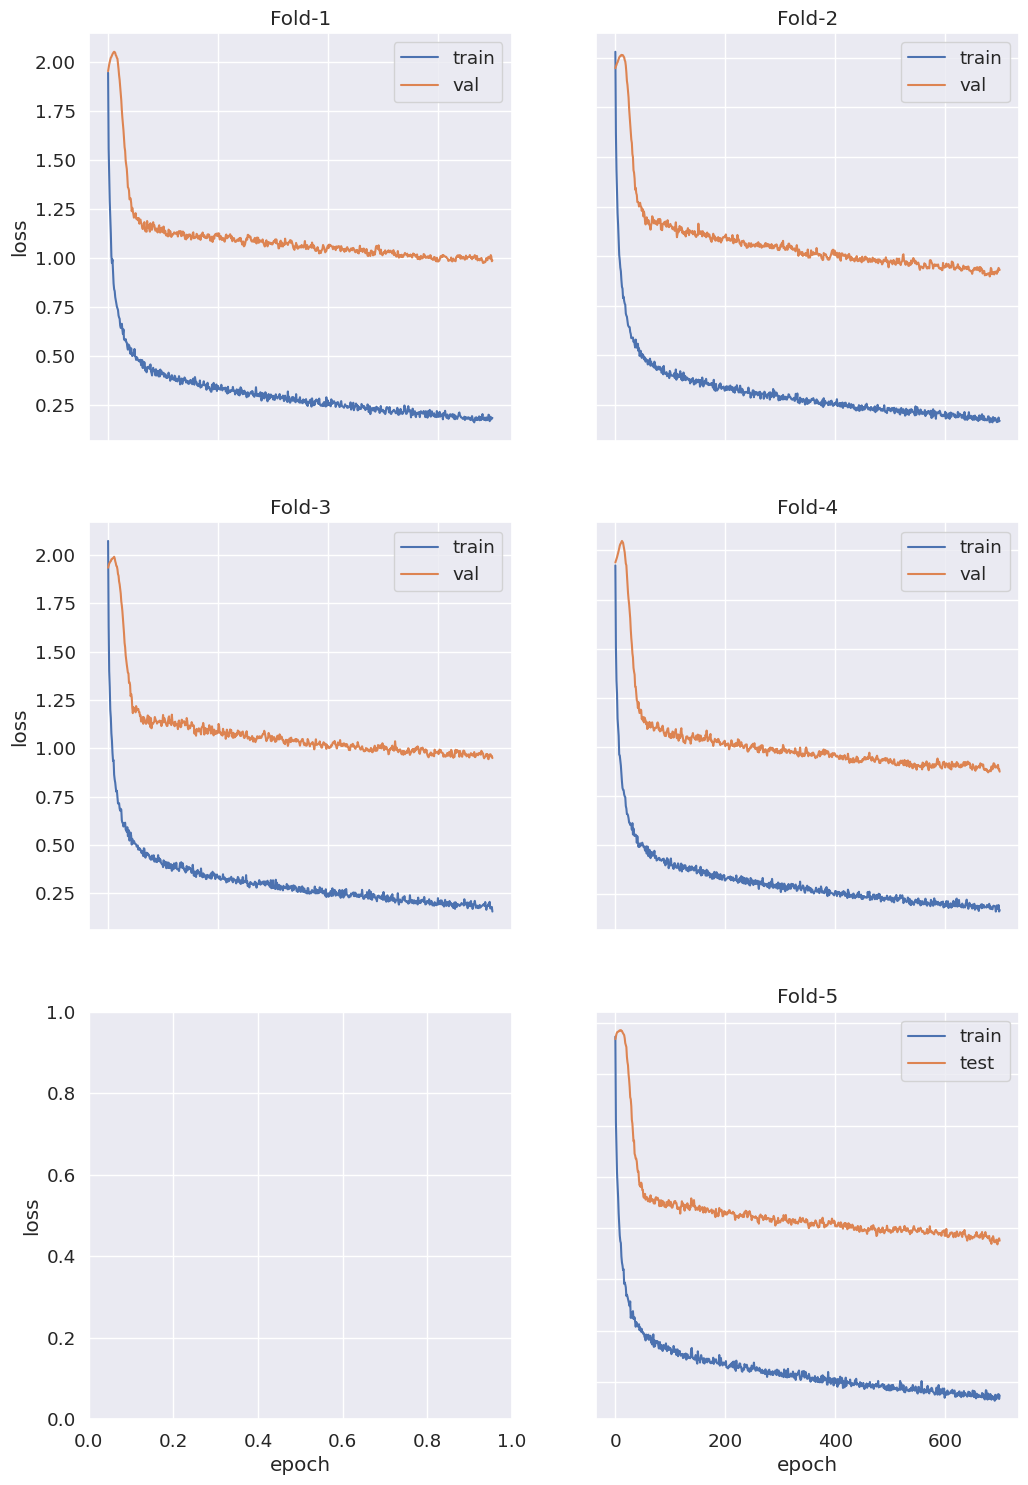

In [74]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(3, 2,figsize=(12,18))
axs[0, 0].plot(hist[0].history['loss'])
axs[0, 0].plot(hist[0].history['val_loss'])
axs[0, 0].set_title('Fold-1')
axs[0, 0].legend(['train', 'val'], loc='upper right')

axs[0, 1].plot(hist[1].history['loss'])
axs[0, 1].plot(hist[1].history['val_loss'])
axs[0, 1].set_title('Fold-2')
axs[0, 1].legend(['train', 'val'], loc='upper right')

axs[1, 0].plot(hist[2].history['loss'])
axs[1, 0].plot(hist[2].history['val_loss'])
axs[1, 0].set_title('Fold-3')
axs[1, 0].legend(['train', 'val'], loc='upper right')

axs[1, 1].plot(hist[3].history['loss'])
axs[1, 1].plot(hist[3].history['val_loss'])
axs[1, 1].set_title('Fold-4')
axs[1, 1].legend(['train', 'val'], loc='upper right')

axs[2, 1].plot(hist[4].history['loss'])
axs[2, 1].plot(hist[4].history['val_loss'])
axs[2, 1].set_title('Fold-5')
axs[2, 1].legend(['train', 'test'], loc='upper right')

for ax in axs.flat:
    ax.set(xlabel='epoch', ylabel='loss')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
fig.savefig('emodbBoth_4Folds_65.png')

In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'emodb_gender_both'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

print("\nMean Accuracy: %.2f%%" % np.mean(accuracies))
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
print("95%% CI: ± %.2f" % ci95)


2025-11-06 15:37:33.466919: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-06 15:37:33.499732: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-06 15:37:34.190611: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-

Fold 0: Accuracy = 71.96%
Fold 1: Accuracy = 74.77%
Fold 2: Accuracy = 75.70%
Fold 3: Accuracy = 77.57%
Fold 4: Accuracy = 73.83%

Mean Accuracy: 74.77%
SD Accuracy: 1.87
95% CI: ± 1.64


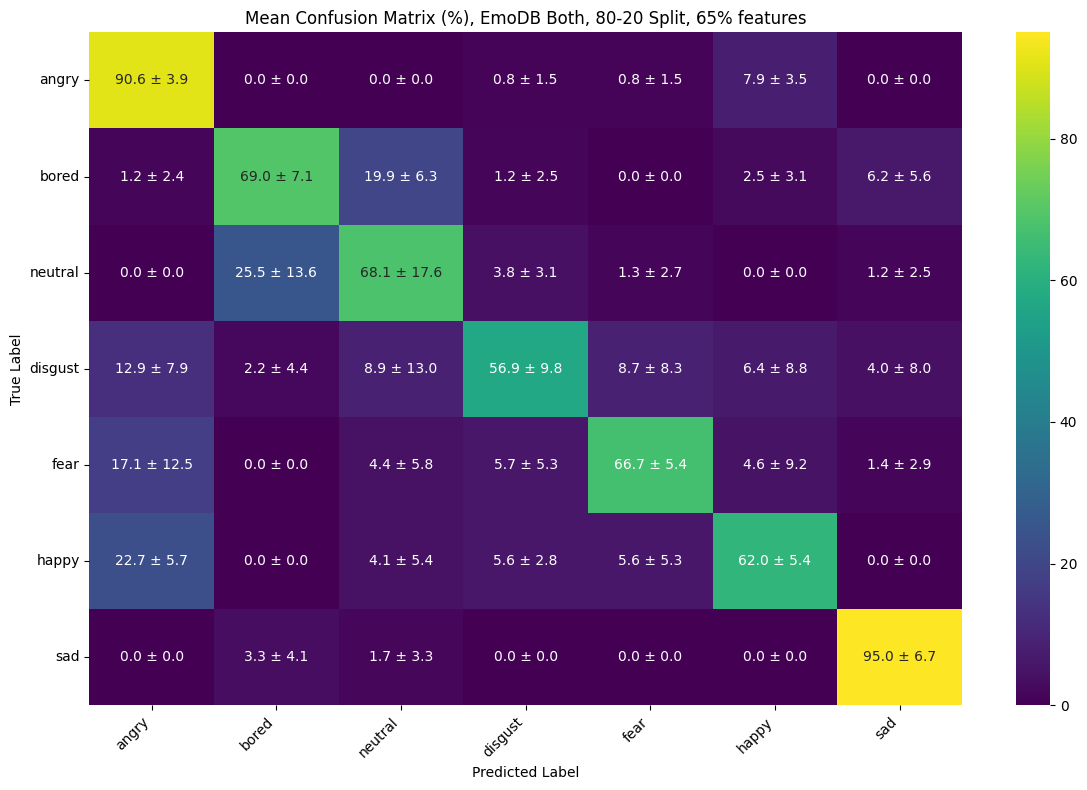

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100
np.save('cm_emodb_gender_both.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        labels[i, j] = f"{mean_cm[i, j]:.1f} ± {std_cm[i, j]:.1f}"

listik = ['angry', 'bored', 'neutral', 'disgust', 'fear', 'happy', 'sad']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(listik, rotation=0)

plt.title("Mean Confusion Matrix (%), EmoDB Both, 80-20 Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
